# PDF to Markdown Integration Test

In this notebook, we perform a controlled test of the production code located in `src/doc_agent/`. Our objective is to verify the integration between the infrastructure (Storage/Manifest), the physical layout parser (Docling), the orientation normalizer (ONNX), and the semantic normalizer (VLM Agent). We will process a single page through the pipeline to ensure it successfully converts a raw PDF into a clean Markdown artifact.

In [2]:
# Enable autoreload to automatically pick up changes in local modules
%load_ext autoreload
%autoreload 2

In [3]:
import logging
import re
from pathlib import Path
from IPython.display import display, Markdown, Image

from doc_agent.configs.settings import settings
from doc_agent.utils.logger import setup_logger
from utils.display_diff import display_diff


# Configure logging
logger = setup_logger(
    name="007_pdf_to_markdown_test_2", 
    level=logging.INFO,
    log_file="integration_test.log"
)
logger.info("Environment initialized.")

2026-05-15 20:03:20 |     INFO | 007_pdf_to_markdown_test_2:1745487485.py:17 - Environment initialized.


## Step 1: Infrastructure Initialization
Loading the `StorageManager` and `ManifestManager` to verify that the isolated workspace is created correctly.

In [4]:
from doc_agent.core.storage import LocalStorageManager
from doc_agent.core.manifest_manager import LocalManifestManager, PageStatus

DOC_ID = "pue_1"
TARGET_PDF = settings.RAW_DIR / "pue_1.pdf" 
WORKSPACE_DIR = settings.PROCESSING_DIR / DOC_ID

# Initialize Core Services
storage = LocalStorageManager(base_dir=WORKSPACE_DIR)
manifest = LocalManifestManager(storage=storage, doc_id=DOC_ID)

logger.info(f"Target PDF: {TARGET_PDF.name}")
logger.info(f"Workspace initialized at: {WORKSPACE_DIR.relative_to(settings.PROJECT_ROOT)}")

logger.info(f"Storage Manager bound to: {storage.base_dir.name}")
logger.info(f"Manifest Manager tracking Doc ID: {manifest.doc_id}")

2026-05-15 20:03:22 |     INFO | 007_pdf_to_markdown_test_2:4104624140.py:12 - Target PDF: pue_1.pdf
2026-05-15 20:03:22 |     INFO | 007_pdf_to_markdown_test_2:4104624140.py:13 - Workspace initialized at: data/02_interim/pue_1
2026-05-15 20:03:22 |     INFO | 007_pdf_to_markdown_test_2:4104624140.py:15 - Storage Manager bound to: pue_1
2026-05-15 20:03:22 |     INFO | 007_pdf_to_markdown_test_2:4104624140.py:16 - Manifest Manager tracking Doc ID: pue_1


## Step 2: Physical Layer (Slicing and Rotation)
Testing the `pdf_processor.py` script. Ensuring the ONNX model loads, slices the PDF, and physically rotates any misaligned pages to a standard upright orientation.

2026-05-15 20:03:31 |     INFO | 007_pdf_to_markdown_test_2:1334426003.py:19 - Slicing complete. Processing page: page_0001
2026-05-15 20:03:31 |     INFO | 007_pdf_to_markdown_test_2:1334426003.py:20 - Original rotation angle was: 0°


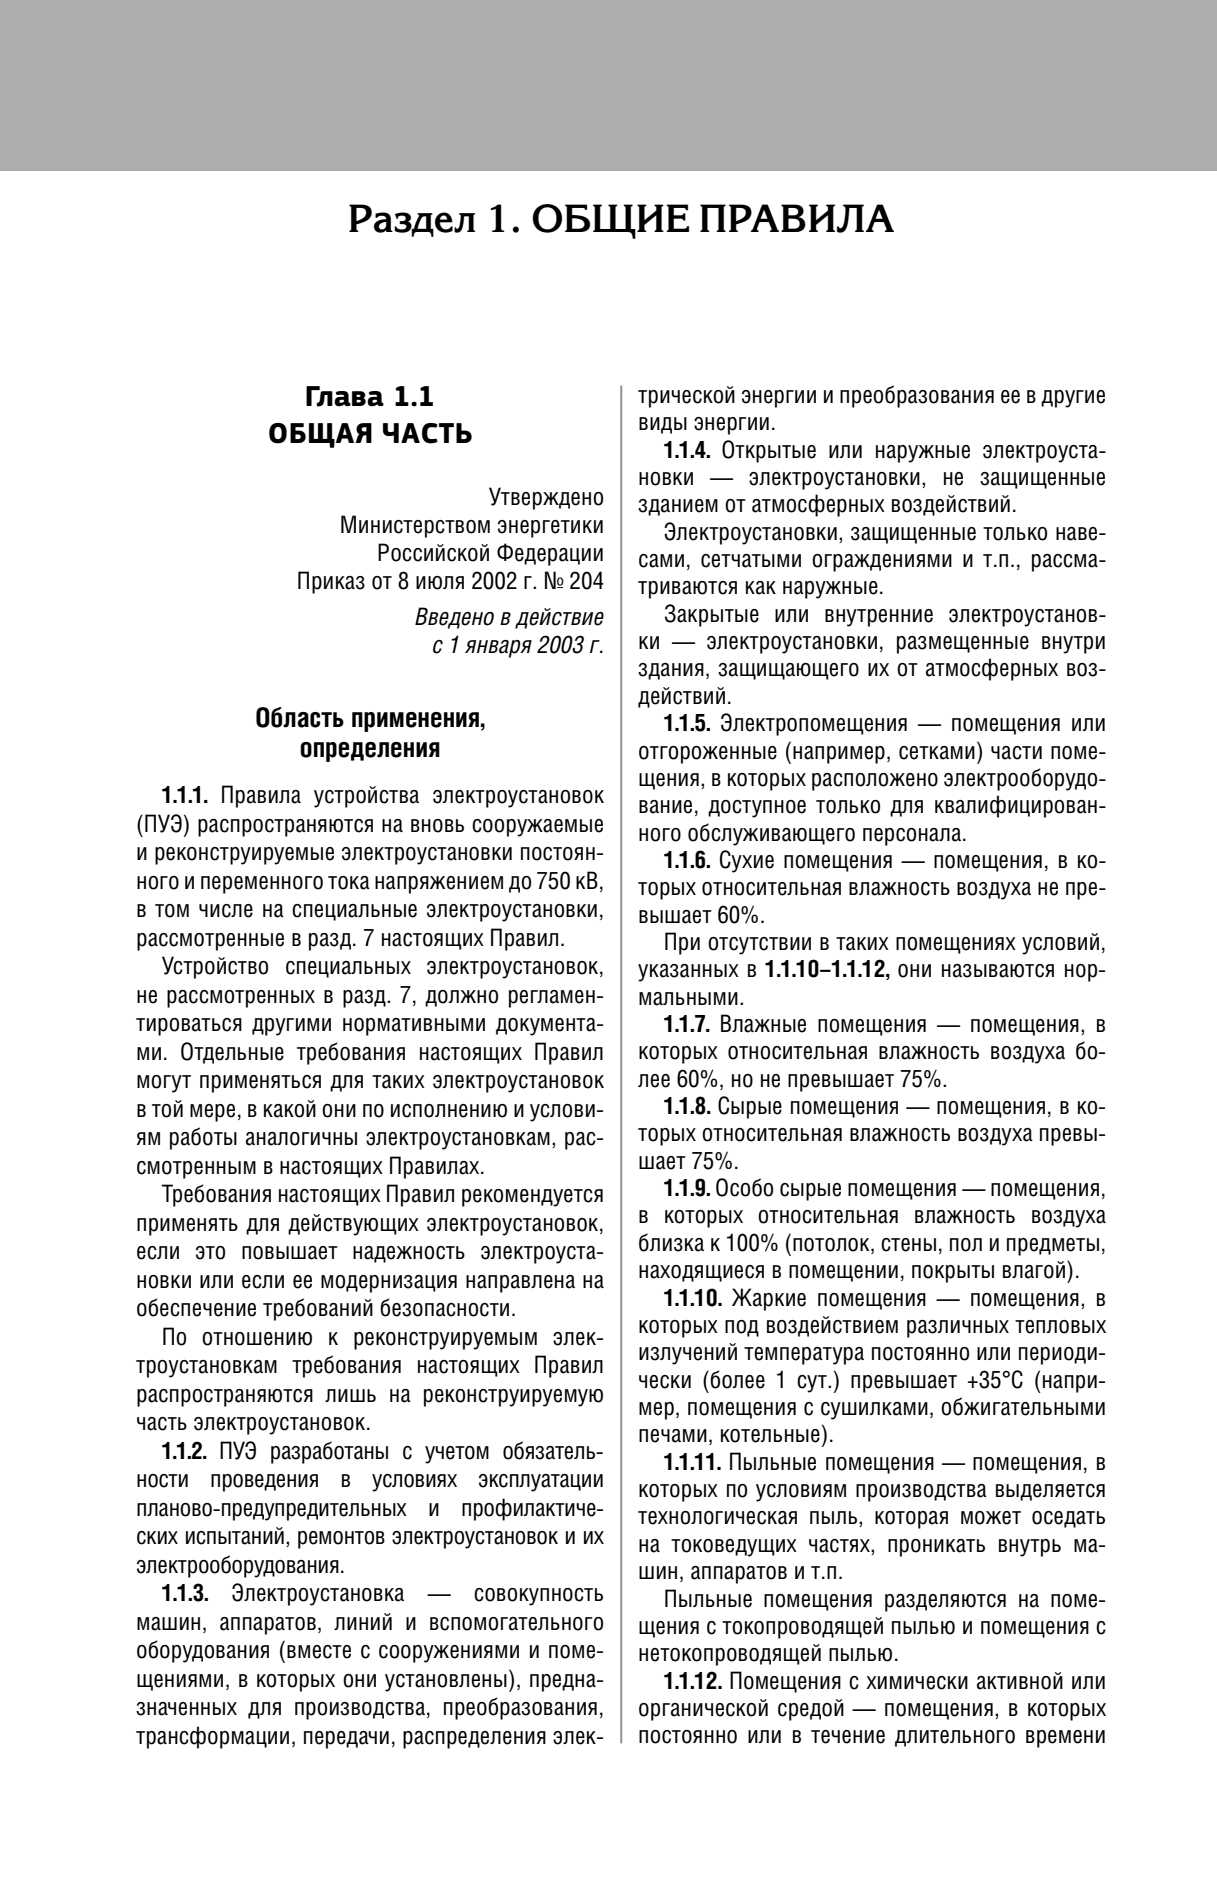

In [5]:
from doc_agent.data.pdf_processor import slice_pdf_to_pages

model_path = settings.PROJECT_ROOT / "models" / "page_orientation.onnx"

# Execute physical processing
pages_data = slice_pdf_to_pages(
    pdf_path=TARGET_PDF,
    workspace_dir=WORKSPACE_DIR,
    model_path=model_path
)

# Initialize the state machine
manifest.init_manifest(source_pdf_path=TARGET_PDF, total_pages=len(pages_data))

# Select the first page for the integration test
test_page = pages_data[0]
page_id = test_page["id"]

logger.info(f"Slicing complete. Processing page: {page_id}")
logger.info(f"Original rotation angle was: {test_page['original_rotation']}°")

# Display the image to visually confirm upright orientation
display(Image(filename=test_page["png"], width=600))

## Step 3: Extraction and Semantic Tagging
Passing the normalized PDF to the Docling parser combined with our `semantic_tagger.py`.

In [7]:
from doc_agent.data.content_extractor import parse_document

logger.info(f"[{page_id}] Starting Docling extraction and tagging...")

# Create a dedicated directory for figures, mirroring the production orchestrator
figures_dir = WORKSPACE_DIR / "05_figures" / page_id

# UNPACK THE TUPLE: retrieve both the tagged text and the list of image paths
tagged_md, figure_paths = parse_document(
    file_path=test_page["pdf"],
    do_formula_enrichment=True,
    generate_picture_images=True,
    do_ocr=False,
    image_output_dir=figures_dir  # Specify the output directory for saved images
)

# Persist the tagged artifact via StorageManager (Pipeline Step 3)
rel_path = f"03_md_tagged/{page_id}.md"
storage.save_text(rel_path, tagged_md)

# Register the artifact inside the manifest
manifest.add_page_artifact(page_id, "tagged_md", rel_path)

# Register the discovered figure paths in the manifest
for fig_path in figure_paths:
    rel_fig = fig_path.relative_to(WORKSPACE_DIR)
    manifest.add_page_figure(page_id, str(rel_fig))

# Update state machine status
manifest.update_page_status(page_id, PageStatus.TAGGED)

logger.info(f"Tagged artifact saved and registered at: {rel_path}")
logger.info(f"Extracted {len(figure_paths)} figures.")
logger.info("Extraction successful. Previewing the first 3000 characters of XML-Markdown:")
print(tagged_md[:3000] + "\n...\n")

2026-05-15 20:10:47 |     INFO | 007_pdf_to_markdown_test_2:238632134.py:3 - [page_0001] Starting Docling extraction and tagging...
2026-05-15 20:11:04 |     INFO | 007_pdf_to_markdown_test_2:238632134.py:32 - Tagged artifact saved and registered at: 03_md_tagged/page_0001.md
2026-05-15 20:11:04 |     INFO | 007_pdf_to_markdown_test_2:238632134.py:33 - Extracted 0 figures.
2026-05-15 20:11:04 |     INFO | 007_pdf_to_markdown_test_2:238632134.py:34 - Extraction successful. Previewing the first 3000 characters of XML-Markdown:
<text_1>
16
</text_1>

<section_header_1>
Ðàçäåë 1. ÎÁÙÈÅ ÏÐÀÂÈËÀ
</section_header_1>

<section_header_2>
Глава 1.1 ОБЩАЯ ЧАСТЬ
</section_header_2>

<text_2>
Утверждено Министерством энергетики Российской Федерации Приказ от 8 июля 2002 г . № 204 Введено в действие с 1 января 2003 г .
</text_2>

<section_header_3>
Область применения , определения
</section_header_3>

<list_item_1>
1.1.1. Правила устройства электроустановок ( ПУЭ ) распространяются на вновь сооружае

## Step 4: VLM Normalization (OCR Healing Agent)
Passing the XML-tagged text and the high-resolution PNG image to our production agent. This verifies the Pydantic data contracts and the LLM API integration.

In [9]:
from doc_agent.agents.ocr_healer import OCRHealerAgent

# Load the final stable prompt 
prompt_path = settings.PROMPTS_DIR / "ocr_healing.md"
system_prompt = prompt_path.read_text(encoding="utf-8")

# Initialize the agent
agent = OCRHealerAgent(
    api_key=settings.NANOGPT_API_KEY,
    base_url=settings.NANOGPT_BASE_URL,
    model_name=settings.TARGET_MODEL
)

logger.info(f"[{page_id}] Starting LLM normalization ({settings.TARGET_MODEL})...")

clean_md = agent.heal_page(
    tagged_text=tagged_md,
    image_path=test_page["png"],
    system_prompt=system_prompt
)

logger.info("Normalization complete! Generating visual Diff:")

# For a fair visual diff comparison, remove XML tags from the raw text using regex
raw_no_tags = re.sub(r'</?[^>]+>', '', tagged_md)

display_diff(
    text_before=raw_no_tags, 
    text_after=clean_md, 
    fromfile='Raw Docling (Tags removed)', 
    tofile='LLM Healed (Production Agent)'
)

# Save temporary md-file for quick IDE preview.
output_path = Path("final_result.md") 
output_path.write_text(clean_md, encoding="utf-8")

logger.info(f"Temporary md-file saved for preview: {output_path.absolute()}")

2026-05-15 20:53:12 |     INFO | 007_pdf_to_markdown_test_2:3915624861.py:14 - [page_0001] Starting LLM normalization (openai/gpt-5-mini)...
2026-05-15 20:54:13 |     INFO | 007_pdf_to_markdown_test_2:3915624861.py:22 - Normalization complete! Generating visual Diff:


```diff
--- Raw Docling (Tags removed)
+++ LLM Healed (Production Agent)
@@ -1,104 +1,75 @@
-
 16
 
+# Раздел 1. ОБЩИЕ ПРАВИЛА
 
+## Глава 1.1 ОБЩАЯ ЧАСТЬ
 
-Ðàçäåë 1. ÎÁÙÈÅ ÏÐÀÂÈËÀ
+Утверждено Министерством энергетики Российской Федерации Приказ от 8 июля 2002 г. № 204. Введено в действие с 1 января 2003 г.
 
+### Область применения, определения
 
+#### 1.1.1. Правила устройства электроустановок (ПУЭ)
 
-Глава 1.1 ОБЩАЯ ЧАСТЬ
+Правила устройства электроустановок (ПУЭ) распространяются на вновь сооружаемые и реконструируемые электроустановки постоянного и переменного тока напряжением до 750 кВ, в том числе на специальные электроустановки, рассмотренные в разд. 7 настоящих Правил.
 
+Устройство специальных электроустановок, не рассмотренных в разд. 7, должно регламентироваться другими нормативными документами. Отдельные требования настоящих Правил могут применяться для таких электроустановок в той мере, в какой они по исполнению и условиям работы аналогичны электроустановкам, рассмотренным в настоящих Правилах.
 
+Требования настоящих Правил рекомендуется применять для действующих электроустановок, если это повышает надежность электроустановки или если ее модернизация направлена на обеспечение требований безопасности.
 
-Утверждено Министерством энергетики Российской Федерации Приказ от 8 июля 2002 г . № 204 Введено в действие с 1 января 2003 г .
+По отношению к реконструируемым электроустановкам требования настоящих Правил распространяются лишь на реконструируемую часть электроустановок.
 
+#### 1.1.2.
 
+ПУЭ разработаны с учетом обязательности проведения в условиях эксплуатации планово-предупредительных и профилактических испытаний, ремонтов электроустановок и их электрооборудования.
 
-Область применения , определения
+#### 1.1.3.
 
+Электроустановка — совокупность машин, аппаратов, линий и вспомогательного оборудования (вместе с сооружениями и помещениями, в которых они установлены), предназначенных для производства, преобразования, трансформации, передачи, распределения электрической энергии и преобразования ее в другие виды энергии.
 
+#### 1.1.4.
 
-1.1.1. Правила устройства электроустановок ( ПУЭ ) распространяются на вновь сооружаемые и реконструируемые электроустановки постоян -ного и переменного тока напряжением до 750 кВ , в том числе на специальные электроустановки , рассмотренные в разд . 7 настоящих Правил .
+Открытые или наружные электроустановки — электроустановки, не защищенные зданием от атмосферных воздействий.
 
+Электроустановки, защищенные только навесами, сетчатыми ограждениями и т.п., рассматриваются как наружные.
 
+Закрытые или внутренние электроустановки — электроустановки, размещенные внутри здания, защищающего их от атмосферных воздействий.
 
-Устройство специальных электроустановок , не рассмотренных в разд .  7, должно регламен -тироваться другими нормативными документа -ми . Отдельные требования настоящих Правил могут применяться для таких электроустановок в той мере , в какой они по исполнению и услови -ям работы аналогичны электроустановкам , рас -смотренным в настоящих Правилах .
+#### 1.1.5.
 
+Электропомещения — помещения или отгороженные (например, сетками) части помещения, в которых расположено электрооборудование, доступное только для квалифицированного обслуживающего персонала.
 
+#### 1.1.6.
 
-Требования настоящих Правил рекомендуется применять для действующих электроустановок , если это повышает надежность электроуста -новки или если ее модернизация направлена на обеспечение требований безопасности .
+Сухие помещения — помещения, в которых относительная влажность воздуха не превышает 60%.
 
+При отсутствии в таких помещениях условий, указанных в 1.1.10–1.1.12, они называются нормальными.
 
+#### 1.1.7.
 
-По отношению к реконструируемым элек -троустановкам требования настоящих Правил распространяются лишь на реконструируемую часть электроустановок .
+Влажные помещения — помещения, в которых относительная влажность воздуха более 60%, но не превышает 75%.
 
+#### 1.1.8.
 
+Сырые помещения — помещения, в которых относительная влажность воздуха превышает 75%.
 
-1.1.2. ПУЭ разработаны с учетом обязатель -ности проведения в условиях эксплуатации планово -предупредительных и профилактиче -ских испытаний , ремонтов электроустановок и их электрооборудования .
+#### 1.1.9.
 
+Особо сырые помещения — помещения, в которых относительная влажность воздуха близка к 100% (потолок, стены, пол и предметы, находящиеся в помещении, покрыты влагой).
 
+#### 1.1.10.
 
-1.1.3. Электроустановка -совокупность машин , аппаратов , линий и вспомогательного оборудования ( вместе с сооружениями и поме -щениями , в которых они установлены ), предна -значенных для производства , преобразования , трансформации , передачи , распределения элек -
+Жаркие помещения — помещения, в которых под воздействием различных тепловых излучений температура постоянно или периодически (более 1 сут.) превышает +35°С (например, помещения с сушилками, обжигательными печами, котельные).
 
+#### 1.1.11.
 
+Пыльные помещения — помещения, в которых по условиям производства выделяется технологическая пыль, которая может оседать на токоведущих частях, проникать внутрь машин, аппаратов и т.п.
 
-трической энергии и преобразования ее в другие виды энергии .
+Пыльные помещения разделяются на помещения с токопроводящей пылью и помещения с нетокопроводящей пылью.
 
+#### 1.1.12.
 
-
-1.1.4. Открытые или наружные электроуста -новки -электроустановки , не защищенные зданием от атмосферных воздействий .
-
-
-
-Электроустановки , защищенные только наве -сами , сетчатыми ограждениями и т . п ., рассма -триваются как наружные .
-
-
-
-Закрытые или внутренние электроустанов -ки -электроустановки , размещенные внутри здания , защищающего их от атмосферных воз -действий .
-
-
-
-1.1.5. Электропомещения -помещения или отгороженные ( например , сетками ) части поме -щения , в которых расположено электрооборудо -вание , доступное только для квалифицирован -ного обслуживающего персонала .
-
-
-
-1.1.6. Сухие помещения -помещения , в ко -торых относительная влажность воздуха не пре -вышает 60%.
-
-
-
-При отсутствии в таких помещениях условий , указанных в 1.1.10-1.1.12, они называются нор -мальными .
-
-
-
-1.1.7. Влажные помещения -помещения , в которых относительная влажность воздуха бо -лее 60%, но не превышает 75%.
-
-
-
-1.1.8. Сырые помещения -помещения , в ко -торых относительная влажность воздуха превы -шает 75%.
-
-
-
-1.1.9. Особо сырые помещения -помещения , в которых относительная влажность воздуха близка к 100% ( потолок , стены , пол и предметы , находящиеся в помещении , покрыты влагой ).
-
-
-
-1.1.10. Жаркие помещения -помещения , в которых под воздействием различных тепловых излучений температура постоянно или периоди -чески ( более 1 сут .) превышает +35° С ( напри -мер , помещения с сушилками , обжигательными печами , котельные ).
-
-
-
-1.1.11. Пыльные помещения -помещения , в которых по условиям производства выделяется технологическая пыль , которая может оседать на токоведущих частях , проникать внутрь ма -шин , аппаратов и т . п .
-
-
-
-Пыльные помещения разделяются на поме -щения с токопроводящей пылью и помещения с нетокопроводящей пылью .
-
-
-
-1.1.12. Помещения с химически активной или органической средой -помещения , в которых постоянно или в течение длительного времени
-
-
+Помещения с химически активной или органической средой — помещения, в которых постоянно или в течение длительного времени...
 
 ПУЭ
 
-
+**==PICTURE_PLACEHOLDER==**
```

2026-05-15 20:54:13 |     INFO | 007_pdf_to_markdown_test_2:3915624861.py:38 - Temporary md-file saved for preview: /Volumes/SSD/AI/doc_agent/notebooks/final_result.md


## Step 5: State Machine Verification
Persisting the results and verifying that the `LocalManifestManager` correctly updated the pipeline history on disk.

In [23]:
## Step 5: State Machine Verification
logger.info(f"[{page_id}] Persisting final cleaned artifact...")

# Persist the final artifact via StorageManager (Pipeline Step 4)
clean_rel_path = f"04_md_clean/{page_id}.md"
storage.save_text(clean_rel_path, clean_md)

# Register the artifact inside the manifest
manifest.add_page_artifact(page_id, "clean_md", clean_rel_path)

# Update final page status
manifest.update_page_status(page_id, PageStatus.CLEANED)

logger.info(f"Cleaned artifact permanently saved at: {clean_rel_path}")

# Verify the manifest state
logger.info("Inspecting final manifest.json file:")
manifest_path = storage.get_absolute_path("manifest.json")
print(manifest_path.read_text(encoding="utf-8"))

2026-05-15 00:09:40 |     INFO | 007_pdf_to_markdown_test:1228390779.py:2 - [page_0001] Persisting final cleaned artifact...
2026-05-15 00:09:40 |     INFO | 007_pdf_to_markdown_test:1228390779.py:14 - Cleaned artifact permanently saved at: 04_md_clean/page_0001.md
2026-05-15 00:09:41 |     INFO | 007_pdf_to_markdown_test:1228390779.py:17 - Inspecting final manifest.json file:
{
  "doc_id": "pue_23_25",
  "source_file": "/Volumes/SSD/AI/doc_agent/data/01_raw/pue_23_25.pdf",
  "total_pages": 3,
  "global_status": "processing",
  "pages": {
    "page_0001": {
      "status": "cleaned",
      "complexity_flags": [],
      "paths": {
        "tagged_md": "03_md_tagged/page_0001.md",
        "clean_md": "04_md_clean/page_0001.md"
      },
      "figures": []
    },
    "page_0002": {
      "status": "pending",
      "complexity_flags": [],
      "paths": {},
      "figures": []
    },
    "page_0003": {
      "status": "pending",
      "complexity_flags": [],
      "paths": {},
      "figur

## Conclusion and Next Steps

The end-to-end integration test for the single-page processing pipeline has completed successfully. We have validated the following core capabilities:

1. **Physical Layer:** Accurate PDF slicing and ONNX-based page orientation normalization.
2. **Semantic Extraction Layer:** Successful Document Layout Analysis (Docling) and XML-tagging of the layout graph.
3. **VLM Normalization:** Accurate hallucination-free healing of parser artifacts and tabular data reconstruction.
4. **State Management:** Flawless file persistence and state tracking via `StorageManager` and `ManifestManager`.

**Next Step:** Transition from this single-page sandbox to the batch-processing orchestration script to handle multi-page documents automatically based on the generated `manifest.json`.